# **Data Preprocessing**

In [ ]:
# !pip install mediapipe==0.10.21

   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
    --------------------------------------- 0.3/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.8/15.8 MB 1.6 MB/s eta 0:00:10
   --- ------------------------------------ 1.3/15.8 MB 1.9 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/15.8 MB 2.1 MB/s eta 0:00:07
   ----- ---------------------------------- 2.1/15.8 MB 2.1 MB/s eta 0:00:07
   ------ --------------------------------- 2.6/15.8 MB 2.1 MB/s eta 0:00:07
   ------- -------------------------------- 3.1/15.8 MB 2.1 MB/s eta 0:00:06
   --------- ------------------------------ 3.7/15.8 MB 2.2 MB/s eta 0:00:06
   --------- ----------------------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorflow-intel 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.12.0 which is incompatible.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.15.0 requires tensorboard<2.16,>=2.15, but you have tensorboard 2.19.0 which is incompatible.


In [1]:
# Import required libraries
import cv2
import os
import glob
import pickle
import numpy as np
from tqdm import tqdm
import mediapipe as mp
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
dataset_path = "Indian Sign Language Greetings Dataset - Sub Variant of INCLUDE"
classes = os.listdir(dataset_path)
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

for class_name in classes:
    video_count = len(glob.glob(os.path.join(dataset_path, class_name, "*.mp4")))
    print(f"{class_name}: {video_count} videos")

Number of classes: 9
Classes: ['Alright', 'Good afternoon', 'Good evening', 'Good Morning', 'Good night', 'Hello', 'How are you', 'Pleased', 'Thank you']
Alright: 21 videos
Good afternoon: 21 videos
Good evening: 21 videos
Good Morning: 21 videos
Good night: 21 videos
Hello: 21 videos
How are you: 21 videos
Pleased: 21 videos
Thank you: 21 videos


Total frames: 63
Frame shape: (1080, 1920, 3)


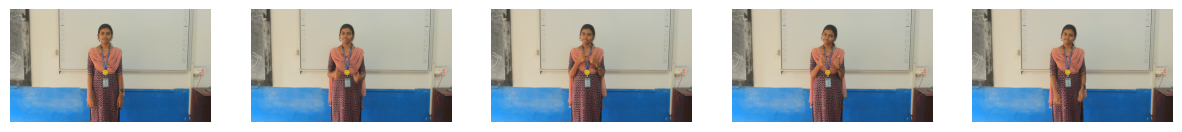

In [11]:
def load_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

# Test with one video
sample_video = "Indian Sign Language Greetings Dataset - Sub Variant of INCLUDE\Alright\MVI_0095.mp4"
frames = load_video(sample_video)
print(f"Total frames: {len(frames)}")
print(f"Frame shape: {frames[0].shape}")

# Visualize some frames
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(frames[i * len(frames) // 5])
    ax.axis('off')
plt.show()

In [12]:
def visualize_sample_frames(video_path, num_frames=5):
    """Visualize evenly spaced frames from a video"""
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    cap.release()

    print(f"📹 Video: {os.path.basename(video_path)}")
    print(f"   Total frames: {len(frames)}")
    print(f"   Frame shape: {frames[0].shape}")

    # Plot evenly spaced frames
    fig, axes = plt.subplots(1, num_frames, figsize=(15, 3))
    for i, ax in enumerate(axes):
        frame_idx = i * len(frames) // num_frames
        ax.imshow(frames[frame_idx])
        ax.set_title(f'Frame {frame_idx}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    return frames

# **Frame Level Augmentation**


In [13]:
# ============================================================================
# STEP 1: FRAME-LEVEL AUGMENTATION (Applied consistently per video)
# ============================================================================

class VideoFrameAugmenter:
    """Augment raw video frames consistently across all frames (frame & video level)"""

    def __init__(self):
        pass

    # ============================================================
    # FRAME-LEVEL AUGMENTATION
    # ============================================================

    def augment_frame(self, frame, aug_params):
        """Apply augmentation to a single frame"""
        augmented = frame.copy()
        h, w = augmented.shape[:2]

        # 0. Center Crop ------------------------------------------------
        crop_factor = aug_params.get("center_crop", 1.0)
        if crop_factor < 1.0:
            new_h, new_w = int(h * crop_factor), int(w * crop_factor)
            y1 = (h - new_h) // 2
            x1 = (w - new_w) // 2
            augmented = augmented[y1:y1+new_h, x1:x1+new_w]
            augmented = cv2.resize(augmented, (w, h))

        # 1. Horizontal flip -------------------------------------------
        if aug_params["flip"]:
            augmented = cv2.flip(augmented, 1)

        # 2. Rotation ---------------------------------------------------
        if aug_params["rotation"] != 0:
            M = cv2.getRotationMatrix2D((w/2, h/2), aug_params["rotation"], 1.0)
            augmented = cv2.warpAffine(augmented, M, (w, h))

        # 3. Brightness -------------------------------------------------
        if aug_params["brightness"] != 1.0:
            augmented = cv2.convertScaleAbs(
                augmented, alpha=aug_params["brightness"], beta=0
            )

        # 4. Zoom -------------------------------------------------------
        if aug_params["zoom"] != 1.0:
            zoom = aug_params["zoom"]
            new_h, new_w = int(h / zoom), int(w / zoom)
            top = (h - new_h) // 2
            left = (w - new_w) // 2
            augmented = augmented[top:top+new_h, left:left+new_w]
            augmented = cv2.resize(augmented, (w, h))

        return augmented

    # ============================================================
    # VIDEO-LEVEL TEMPORAL AUGMENTATION
    # ============================================================

    def temporal_upsample(self, frames, factor=1.5):
        """Slow motion: duplicate frames to increase frame count"""
        new_frames = []
        for f in frames:
            repeat = int(factor)
            for _ in range(repeat):
                new_frames.append(f.copy())
        return new_frames

    def temporal_downsample(self, frames, factor=1.5):
        """Fast motion: drop frames to reduce frame count"""
        step = int(factor)
        return frames[::step]

    def apply_temporal_augmentation(self, frames, temporal_type):
        """Apply temporal augmentation to entire video"""
        if temporal_type == "upsample":
            return self.temporal_upsample(frames, factor=1.5)
        elif temporal_type == "downsample":
            return self.temporal_downsample(frames, factor=1.5)
        else:  # "none"
            return frames

    # ============================================================
    # PARAMETER GENERATOR
    # ============================================================

    def generate_augmentation_params(self, num_augmentations=3):
        """Generate random augmentation parameters"""
        aug_params_list = []

        # Always include original (no augmentation)
        aug_params_list.append({
            "flip": False,
            "rotation": 0,
            "brightness": 1.0,
            "zoom": 1.0,
            "center_crop": 1.0,
            "temporal": "none"
        })

        # Generate random augmentations
        for _ in range(num_augmentations):
            aug_params_list.append({
                "flip": np.random.choice([True, False]),
                "rotation": 0,
                "brightness": np.random.uniform(0.8, 1.2),
                "zoom": 1.0,
                "center_crop": 1.0,
                "temporal": np.random.choice(["none", "upsample", "downsample"])
            })

        return aug_params_list

In [14]:
def visualize_frame_augmentations(frame, augmenter):
    """Show original frame + augmented versions"""
    aug_params_list = augmenter.generate_augmentation_params(num_augmentations=4)

    fig, axes = plt.subplots(len(aug_params_list), 1, figsize=(6, 10))
    fig.suptitle('Frame-Level Augmentations', fontsize=16, fontweight='bold')

    for i, (ax, aug_params) in enumerate(zip(axes, aug_params_list)):
        augmented = augmenter.augment_frame(frame, aug_params)
        ax.imshow(cv2.cvtColor(augmented, cv2.COLOR_BGR2RGB))

        # Create label
        label = "Original" if i == 0 else f"Aug {i}"
        details = []
        if aug_params['flip']:
            details.append("Flip")
        if aug_params['rotation'] != 0:
            details.append(f"Rot:{aug_params['rotation']:.1f}°")
        if aug_params['brightness'] != 1.0:
            details.append(f"Bright:{aug_params['brightness']:.2f}")
        if aug_params['zoom'] != 1.0:
            details.append(f"Zoom:{aug_params['zoom']:.2f}")
        if aug_params.get('center_crop', 1.0) < 1.0:
            details.append(f"Crop:{aug_params['center_crop']:.2f}")
        if aug_params.get('temporal', 'none') != 'none':
            details.append(f"Tempo:{aug_params['temporal']}")

        title = label if i == 0 else f"{label}\n{', '.join(details)}"
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

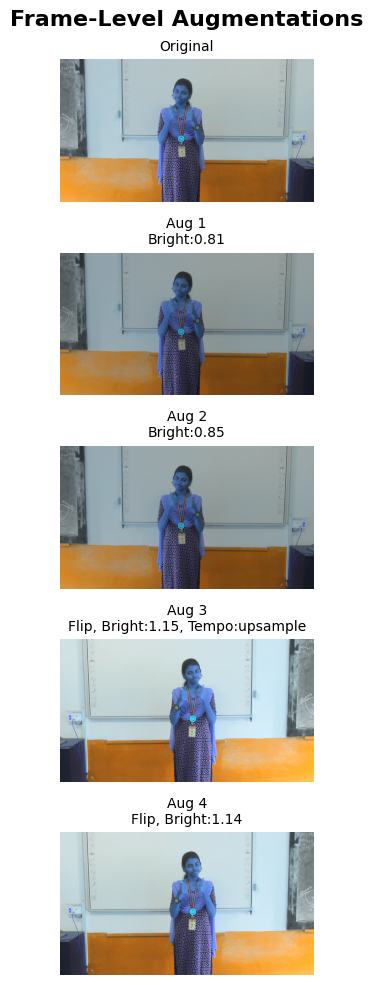

In [15]:
augmenter = VideoFrameAugmenter()
visualize_frame_augmentations(frames[int(np.random.uniform(0, len(frames)))], augmenter)

# **Mediapipe Landmark Extraction**

In [9]:
# ============================================================================
# STEP 2: MEDIAPIPE LANDMARK EXTRACTION
# ============================================================================

class MediaPipeLandmarkExtractor:
    """Extract hand, pose, and face landmarks using MediaPipe"""

    def __init__(self, include_pose=True, include_face=False):
        self.mp_holistic = mp.solutions.holistic
        self.include_pose = include_pose
        self.include_face = include_face

    def relative_normalize(self, lh, rh, pose):
      # Choose wrist as origin
      if np.any(rh):
          origin = rh.reshape(21,3)[0]
      elif np.any(lh):
          origin = lh.reshape(21,3)[0]
      else:
          origin = np.zeros(3)

      lh = lh.reshape(21,3) - origin
      rh = rh.reshape(21,3) - origin

      pose = pose.reshape(33,4)
      pose[:,:3] -= origin

      # Scale by shoulder width
      l_shoulder = pose[11][:3]
      r_shoulder = pose[12][:3]
      scale = np.linalg.norm(l_shoulder - r_shoulder) + 1e-6

      lh /= scale
      rh /= scale
      pose[:,:3] /= scale

      return np.concatenate([lh.flatten(), rh.flatten(), pose.flatten()])

    def extract_landmarks(self, frame, holistic_model):
        """Extract landmarks from a single frame"""
        # Convert BGR to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False

        # Process with MediaPipe
        results = holistic_model.process(image)

        # Extract keypoints
        landmarks = []

        # Left hand (21 landmarks x 3 coordinates = 63 values)
        if results.left_hand_landmarks:
            lh = np.array([[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark]).flatten()
        else:
            lh = np.zeros(21 * 3)
        landmarks.append(lh)

        # Right hand (21 landmarks x 3 coordinates = 63 values)
        if results.right_hand_landmarks:
            rh = np.array([[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark]).flatten()
        else:
            rh = np.zeros(21 * 3)
        landmarks.append(rh)

        # Pose (33 landmarks x 4 values = 132 values) - OPTIONAL
        if self.include_pose:
            if results.pose_landmarks:
                pose = np.array([[lm.x, lm.y, lm.z, lm.visibility]
                               for lm in results.pose_landmarks.landmark]).flatten()
            else:
                pose = np.zeros(33 * 4)
            landmarks.append(pose)

        # Face (468 landmarks x 3 coordinates = 1404 values) - OPTIONAL
        if self.include_face:
            if results.face_landmarks:
                face = np.array([[lm.x, lm.y, lm.z]
                               for lm in results.face_landmarks.landmark]).flatten()
            else:
                face = np.zeros(468 * 3)
            landmarks.append(face)

        return self.relative_normalize(lh, rh, pose)

    def process_video(self, video_path, max_frames=60, augment_params=None):
        """Process entire video and extract landmark sequences"""
        cap = cv2.VideoCapture(video_path)
        frames = []

        # Step 1: Load all frames
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            # Return zero landmarks if video failed to load
            dummy_landmarks = self.extract_landmarks_dummy()
            return np.array([dummy_landmarks] * max_frames)

        # Step 2: Apply temporal augmentation (if specified)
        if augment_params is not None and "temporal" in augment_params:
            augmenter = VideoFrameAugmenter()
            frames = augmenter.apply_temporal_augmentation(frames, augment_params["temporal"])

        # Step 3: Apply frame-level augmentation and extract landmarks
        landmark_sequence = []

        with self.mp_holistic.Holistic(
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        ) as holistic:

            for i, frame in enumerate(frames):
                if i >= max_frames:
                    break

                # Apply frame augmentation if params provided
                if augment_params is not None:
                    frame = VideoFrameAugmenter().augment_frame(frame, augment_params)

                # Extract landmarks
                landmarks = self.extract_landmarks(frame, holistic)
                landmark_sequence.append(landmarks)

        # Step 4: Pad sequence if shorter than max_frames
        if len(landmark_sequence) > 0:
            while len(landmark_sequence) < max_frames:
                landmark_sequence.append(np.zeros_like(landmark_sequence[0]))
        else:
            # Fallback if no landmarks extracted
            dummy_landmarks = self.extract_landmarks_dummy()
            landmark_sequence = [dummy_landmarks] * max_frames

        return np.array(landmark_sequence[:max_frames])

    def extract_landmarks_dummy(self):
        """Create dummy zero landmarks (for error cases)"""
        lh = np.zeros(21 * 3)
        rh = np.zeros(21 * 3)
        landmarks = [lh, rh]

        if self.include_pose:
            landmarks.append(np.zeros(33 * 4))
        if self.include_face:
            landmarks.append(np.zeros(468 * 3))

        return np.concatenate(landmarks)

In [12]:
def draw_mediapipe_landmarks(frame, results):
    mp_drawing = mp.solutions.drawing_utils
    mp_holistic = mp.solutions.holistic

    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            results.left_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )

    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            results.right_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS
        )

    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            results.pose_landmarks,
            mp_holistic.POSE_CONNECTIONS
        )

    return frame

In [10]:
def save_landmark_video(video_path, output_path, augment_params=None):
    cap = cv2.VideoCapture(video_path)

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS)) or 25

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    with mp.solutions.holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if augment_params is not None:
                frame = VideoFrameAugmenter().augment_frame(frame, augment_params)

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            frame = draw_mediapipe_landmarks(frame, results)
            out.write(frame)

    cap.release()
    out.release()

In [14]:
os.makedirs('outputs/', exist_ok=True)
output_video = "outputs/landmarks_debug.mp4"
augmenter = VideoFrameAugmenter()
aug_params = augmenter.generate_augmentation_params()[0]

save_landmark_video(
    sample_video,
    output_video,
    augment_params=aug_params
)

# **Landmark Level Augmentation**

In [18]:
# ============================================================================
# STEP 3: LANDMARK-LEVEL AUGMENTATION
# ============================================================================

class LandmarkAugmenter:
    """Augment landmark sequences (temporal and spatial)"""

    @staticmethod
    def jitter_hands_only(sequence, noise_factor=0.015):
      seq = sequence.copy()
      hand_dim = 21 * 3 * 2  # left + right hands
      seq[:, :hand_dim] += np.random.normal(
          0, noise_factor, seq[:, :hand_dim].shape
      )
      return seq

    # def scale_landmarks(sequence, scale_range=(0.9, 1.1)):
    #     """Scale landmarks (simulate distance variation)"""
    #     scale = np.random.uniform(scale_range[0], scale_range[1])
    #     return sequence * scale

    # def rotate_landmarks_2d(sequence, angle_range=(-10, 10)):
    #     """Rotate landmarks in 2D plane (x, y coordinates)"""
    #     angle = np.radians(np.random.uniform(angle_range[0], angle_range[1]))
    #     cos_a, sin_a = np.cos(angle), np.sin(angle)

    #     # Assuming landmarks are [x, y, z, x, y, z, ...]
    #     # We'll rotate every (x, y) pair
    #     rotated = sequence.copy()
    #     num_features = sequence.shape[1]

    #     # Rotate x, y coordinates (every 3 values for 3D landmarks)
    #     for i in range(0, num_features - 2, 3):
    #         x, y = sequence[:, i], sequence[:, i + 1]
    #         rotated[:, i] = x * cos_a - y * sin_a
    #         rotated[:, i + 1] = x * sin_a + y * cos_a

    #     return rotated

    @staticmethod
    def temporal_stretch(sequence, stretch_range=(0.8, 1.2)):
        """Time warping - stretch or compress sequence temporally"""
        stretch_factor = np.random.uniform(stretch_range[0], stretch_range[1])
        original_length = len(sequence)
        new_length = int(original_length * stretch_factor)

        # Resample sequence
        indices = np.linspace(0, original_length - 1, new_length).astype(int)
        stretched = sequence[indices]

        # Pad or truncate to original length
        if len(stretched) < original_length:
            padding = np.zeros((original_length - len(stretched), sequence.shape[1]))
            stretched = np.vstack([stretched, padding])
        else:
            stretched = stretched[:original_length]

        return stretched

    @staticmethod
    def augment_sequence(sequence, num_augmentations=2):
        """Apply random augmentations to a landmark sequence"""
        augmented_sequences = [sequence]  # Include original

        for _ in range(num_augmentations):
            aug_seq = sequence.copy()

            # Randomly apply augmentations
            if np.random.rand() > 0.3:
                aug_seq = LandmarkAugmenter.jitter_hands_only(aug_seq)

            if np.random.rand() > 0.6:
                aug_seq = LandmarkAugmenter.temporal_stretch(aug_seq)
            augmented_sequences.append(aug_seq)

        return augmented_sequences

# **Dataset Processing Pipeline**

In [19]:
def plot_class_distribution(y, class_names):
    """Plot distribution of samples across classes"""
    unique, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(unique)), counts, color='steelblue', alpha=0.8, edgecolor='black')

    # Add value labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontweight='bold')

    plt.xlabel('Class', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
    plt.title('Class Distribution After Augmentation', fontsize=14, fontweight='bold')
    plt.xticks(range(len(unique)), class_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [20]:
def plot_feature_statistics(X, class_names):
    """Plot statistics of extracted features"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Feature mean across all samples
    feature_means = np.mean(X, axis=(0, 1))
    axes[0, 0].plot(feature_means, linewidth=1.5, color='steelblue')
    axes[0, 0].set_title('Mean Feature Values Across Dataset', fontweight='bold')
    axes[0, 0].set_xlabel('Feature Index')
    axes[0, 0].set_ylabel('Mean Value')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Feature variance
    feature_vars = np.var(X, axis=(0, 1))
    axes[0, 1].plot(feature_vars, linewidth=1.5, color='coral')
    axes[0, 1].set_title('Feature Variance Across Dataset', fontweight='bold')
    axes[0, 1].set_xlabel('Feature Index')
    axes[0, 1].set_ylabel('Variance')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Sequence length distribution (non-zero frames)
    seq_lengths = []
    for sample in X:
        non_zero = np.sum(np.any(sample != 0, axis=1))
        seq_lengths.append(non_zero)

    axes[1, 0].hist(seq_lengths, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Distribution of Sequence Lengths', fontweight='bold')
    axes[1, 0].set_xlabel('Number of Non-Zero Frames')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(np.mean(seq_lengths), color='red', linestyle='--',
                       label=f'Mean: {np.mean(seq_lengths):.1f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Sample frame energy over time (average across all samples)
    frame_energy = np.mean(np.sum(np.abs(X), axis=2), axis=0)
    axes[1, 1].plot(frame_energy, linewidth=2, color='purple')
    axes[1, 1].set_title('Average Landmark Energy Over Time', fontweight='bold')
    axes[1, 1].set_xlabel('Frame Number')
    axes[1, 1].set_ylabel('Total Landmark Magnitude')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [21]:
# ============================================================================
# STEP 4: DATASET PROCESSING PIPELINE
# ============================================================================

def process_dataset(dataset_path, max_frames=60,
                   frame_aug_count=2, landmark_aug_count=2,
                   include_pose=True, include_face=False,
                   visualize_samples=False):
    """
    Complete pipeline: Frame Aug → MediaPipe → Landmark Aug

    Args:
        dataset_path: Path to dataset with structure: dataset_path/class_name/*.mp4
        max_frames: Maximum frames per video
        frame_aug_count: Number of frame-level augmentations
        landmark_aug_count: Number of landmark-level augmentations
        include_pose: Include pose landmarks
        include_face: Include face landmarks
        visualize_samples: Show visualizations during processing
    """

    X = []
    y = []

    classes = sorted([d for d in os.listdir(dataset_path)
                     if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Found {len(classes)} classes: {classes}")

    extractor = MediaPipeLandmarkExtractor(include_pose=include_pose, include_face=include_face)
    augmenter = VideoFrameAugmenter()

    # # VISUALIZATION 1: Show sample video frames from first class
    if visualize_samples and len(classes) > 0:
        first_class_path = os.path.join(dataset_path, classes[0])
        sample_videos = glob.glob(os.path.join(first_class_path, "*.mp4"))
        if len(sample_videos) > 0:
            print("\n" + "="*80)
            print("📊 VISUALIZATION 1: Sample Video Frames")
            print("="*80)
            sample_frames = visualize_sample_frames(sample_videos[0], num_frames=5)

            # VISUALIZATION 2: Show frame augmentations
            print("\n" + "="*80)
            print("📊 VISUALIZATION 2: Frame-Level Augmentations")
            print("="*80)
            sample_frame_bgr = cv2.cvtColor(sample_frames[len(sample_frames)//2], cv2.COLOR_RGB2BGR)
            visualize_frame_augmentations(sample_frame_bgr, augmenter)

    # Process all videos
    first_video_processed = False

    for class_idx, class_name in enumerate(tqdm(classes, desc="Processing classes")):
        class_path = os.path.join(dataset_path, class_name)
        video_files = glob.glob(os.path.join(class_path, "*.mp4"))

        print(f"\n{class_name}: {len(video_files)} videos")

        for video_idx, video_file in enumerate(tqdm(video_files, desc=f"Videos in {class_name}", leave=False)):

            # Generate frame augmentation parameters
            aug_params_list = augmenter.generate_augmentation_params(num_augmentations=frame_aug_count)

            for aug_params in aug_params_list:
                # Extract landmarks with frame augmentation
                landmark_seq = extractor.process_video(
                    video_file,
                    max_frames=max_frames,
                    augment_params=aug_params
                )

                # Apply landmark-level augmentation
                augmented_landmark_seqs = LandmarkAugmenter.augment_sequence(
                    landmark_seq,
                    num_augmentations=landmark_aug_count
                )

                for aug_landmark_seq in augmented_landmark_seqs:
                    X.append(aug_landmark_seq)
                    y.append(class_idx)

    X = np.array(X)
    y = np.array(y)

    print(f"\n✅ Dataset processed!")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Total samples: {len(X)}")
    print(f"Samples per class: {len(X) // len(classes)}")

    # VISUALIZATION 6: Class distribution
    if visualize_samples:
        print("\n" + "="*80)
        print("📊 VISUALIZATION 6: Class Distribution")
        print("="*80)
        plot_class_distribution(y, classes)

        # VISUALIZATION 7: Feature statistics
        print("\n" + "="*80)
        print("📊 VISUALIZATION 7: Feature Statistics")
        print("="*80)
        plot_feature_statistics(X, classes)

    return X, y, classes

# **Graph Convolutional Network (GCN) Model**

In [4]:
# ============================================================================
# GCN SETUP: Define skeletal graph structure
# ============================================================================

def get_adjacency_matrix():
    """
    Define adjacency for: left_hand(21) + right_hand(21) + pose(33) = 75 joints
    Indices: 0-20 = left hand, 21-41 = right hand, 42-74 = pose
    """
    num_joints = 75
    A = np.zeros((num_joints, num_joints), dtype=np.float32)

    # MediaPipe hand connections (same for both hands)
    hand_connections = [
        (0,1),(1,2),(2,3),(3,4),          # thumb
        (0,5),(5,6),(6,7),(7,8),           # index
        (0,9),(9,10),(10,11),(11,12),      # middle
        (0,13),(13,14),(14,15),(15,16),    # ring
        (0,17),(17,18),(18,19),(19,20),    # pinky
        (5,9),(9,13),(13,17)               # palm
    ]

    # Left hand (offset 0)
    for i, j in hand_connections:
        A[i, j] = 1; A[j, i] = 1

    # Right hand (offset 21)
    for i, j in hand_connections:
        A[i+21, j+21] = 1; A[j+21, i+21] = 1

    # MediaPipe pose connections (offset 42)
    pose_connections = [
        (0,1),(1,2),(2,3),(3,7),           # face left
        (0,4),(4,5),(5,6),(6,8),           # face right
        (9,10),                            # mouth
        (11,12),(11,13),(13,15),           # left arm
        (12,14),(14,16),                   # right arm
        (11,23),(12,24),(23,24),           # torso
        (23,25),(25,27),(27,29),(29,31),   # left leg
        (24,26),(26,28),(28,30),(30,32),   # right leg
        (15,17),(15,19),(15,21),           # left hand tips
        (16,18),(16,20),(16,22),           # right hand tips
        (27,31),(28,32)
    ]

    for i, j in pose_connections:
        A[i+42, j+42] = 1; A[j+42, i+42] = 1

    # Cross-body connections: wrists to pose wrists
    # Left hand wrist (0) → Pose left wrist (15+42=57)
    A[0, 57] = 1; A[57, 0] = 1
    # Right hand wrist (21) → Pose right wrist (16+42=58)
    A[21, 58] = 1; A[58, 21] = 1

    # Add self-loops
    np.fill_diagonal(A, 1)

    # Normalize: D^(-1/2) * A * D^(-1/2)
    D = np.diag(np.sum(A, axis=1) ** -0.5)
    A_norm = D @ A @ D

    return A_norm.astype(np.float32)

In [5]:
# ============================================================================
# GCN LAYER & MODEL
# ============================================================================

class GCNLayer(tf.keras.layers.Layer):

    def __init__(self, out_features, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.out_features = out_features
        self.activation_name = activation
        self.activation_fn = tf.keras.activations.get(activation)

    def build(self, input_shape):
        in_features = input_shape[-1]
        self.W = self.add_weight(shape=(in_features, self.out_features),
                                 initializer='glorot_uniform', trainable=True, name='gcn_weight')
        self.b = self.add_weight(shape=(self.out_features,),
                                 initializer='zeros', trainable=True, name='gcn_bias')

    def call(self, x, A):
        support = tf.matmul(x, self.W) + self.b
        output = tf.matmul(A, support)
        return self.activation_fn(output)

    def get_config(self):
        config = super().get_config()
        config.update({'out_features': self.out_features, 'activation': self.activation_name})
        return config


class GCNStep(tf.keras.layers.Layer):
    """Per-frame GCN with baked-in adjacency — fully serializable, no Lambda"""

    def __init__(self, out_features, A, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.out_features = out_features
        self.activation_name = activation
        self.A_init = A
        self.gcn = GCNLayer(out_features, activation=activation)

    def build(self, input_shape):
        self.A = self.add_weight(
            shape=self.A_init.shape,
            initializer=tf.keras.initializers.Constant(self.A_init),
            trainable=False,
            name='adjacency'
        )
        super().build(input_shape)

    def call(self, x):
        A_batch = tf.tile(tf.expand_dims(self.A, 0), [tf.shape(x)[0], 1, 1])
        return self.gcn(x, A_batch)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], self.out_features)

    def get_config(self):
        config = super().get_config()
        config.update({
            'out_features': self.out_features,
            'activation': self.activation_name,
            'A': self.A_init.tolist()
        })
        return config

    @classmethod
    def from_config(cls, config):
        config['A'] = np.array(config['A'], dtype=np.float32)
        return cls(**config)


def build_gcn_lstm_model(num_joints, joint_features, seq_len, num_classes, A):

    inputs = tf.keras.Input(shape=(seq_len, num_joints * joint_features))

    x = tf.keras.layers.Reshape((seq_len, num_joints, joint_features))(inputs)

    x = tf.keras.layers.TimeDistributed(
        GCNStep(64, A, activation='relu', name='gcn_step1'), name='td_gcn1'
    )(x)

    x = tf.keras.layers.TimeDistributed(
        GCNStep(128, A, activation='relu', name='gcn_step2'), name='td_gcn2'
    )(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Flatten(), name='td_flatten'
    )(x)

    x = tf.keras.layers.Masking(mask_value=0.0)(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.2), name='bilstm1'
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128, return_sequences=False, dropout=0.2), name='bilstm2'
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [6]:
# ============================================================================
# RESHAPE LANDMARKS FOR GCN INPUT
# ============================================================================

def reshape_landmarks_for_gcn(X):
    """
    Convert flat landmark array → per-joint feature array.

    Input X shape:  (samples, seq_len, 258)
      258 = left_hand(63) + right_hand(63) + pose(132)
           = 21*3  +  21*3  +  33*4

    Output shape: (samples, seq_len, 75, 4)
      75 joints, each with up to 4 features (x, y, z, [visibility or 0])
    """
    samples, seq_len, _ = X.shape
    num_joints = 75  # 21 + 21 + 33

    out = np.zeros((samples, seq_len, num_joints, 4), dtype=np.float32)

    # Left hand: joints 0-20, features x,y,z (no visibility → pad 0)
    lh = X[:, :, 0:63].reshape(samples, seq_len, 21, 3)
    out[:, :, 0:21, :3] = lh

    # Right hand: joints 21-41
    rh = X[:, :, 63:126].reshape(samples, seq_len, 21, 3)
    out[:, :, 21:42, :3] = rh

    # Pose: joints 42-74, features x,y,z,visibility
    pose = X[:, :, 126:258].reshape(samples, seq_len, 33, 4)
    out[:, :, 42:75, :] = pose

    return out  # (samples, seq_len, 75, 4)

# **Bidirectional LSTM Model**

In [22]:
# ============================================================================
# STEP 5: BUILD BIDIRECTIONAL LSTM MODEL
# ============================================================================

# def build_bilstm_model(input_shape, num_classes):
#     """Build Bidirectional LSTM model for sign language recognition"""

#     model = Sequential([
#         # Masking layer to handle variable-length sequences (padded with zeros)
#         Masking(mask_value=0.0, input_shape=input_shape),

#         # First BiLSTM layer
#         Bidirectional(LSTM(256, return_sequences=True, dropout=0.2, recurrent_activation='hard_sigmoid', use_cudnn=False)),
#         BatchNormalization(),

#         # Second BiLSTM layer
#         Bidirectional(LSTM(128, return_sequences=False, dropout=0.2, recurrent_activation='hard_sigmoid', use_cudnn=False)),
#         BatchNormalization(),

#         # Dense layers
#         Dense(256, activation='relu'),
#         Dropout(0.5),

#         Dense(128, activation='relu'),
#         Dropout(0.3),

#         # Output layer
#         Dense(num_classes, activation='softmax')
#     ])

#     model.compile(
#         optimizer=Adam(learning_rate=0.001),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# **Training Pipeline**

In [23]:
# # ============================================================================
# # STEP 6: TRAINING PIPELINE
# # ============================================================================

# def train_model(X, y, class_names, epochs=100, batch_size=16):
#     """Train the BiLSTM model"""

#     # Train-test split (stratified)
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=42, stratify=y
#     )

#     # Convert to one-hot encoding
#     num_classes = len(class_names)
#     y_train_cat = to_categorical(y_train, num_classes)
#     y_test_cat = to_categorical(y_test, num_classes)

#     print(f"\n📊 Training set: {X_train.shape}")
#     print(f"📊 Test set: {X_test.shape}")

#     # Build model
#     model = build_bilstm_model(
#         input_shape=(X_train.shape[1], X_train.shape[2]),
#         num_classes=num_classes
#     )

#     model.summary()

#     # Callbacks
#     callbacks = [
#         EarlyStopping(
#             monitor='val_loss',
#             patience=20,
#             restore_best_weights=True,
#             verbose=1
#         ),
#         ModelCheckpoint(
#             'outputs/best_isl_model.keras',
#             monitor='val_accuracy',
#             save_best_only=True,
#             verbose=1
#         ),
#         ReduceLROnPlateau(
#             monitor='val_loss',
#             factor=0.5,
#             patience=5,
#             min_lr=1e-6,
#             verbose=1
#         )
#     ]

#     class_weights = compute_class_weight(
#           class_weight='balanced',
#           classes=np.unique(y_train),
#           y=y_train
#     )
#     class_weights = dict(enumerate(class_weights))

#     # Train
#     print("\n🚀 Starting training...")
#     history = model.fit(
#         X_train, y_train_cat,
#         validation_data=(X_test, y_test_cat),
#         epochs=epochs,
#         batch_size=batch_size,
#         callbacks=callbacks,
#         class_weight=class_weights,
#         verbose=1
#     )

#     return model, history, X_test, y_test_cat

In [25]:
# ============================================================================
# STEP 6: TRAINING PIPELINE
# ============================================================================

def train_model(X, y, class_names, epochs=100, batch_size=16):
    """Train the GCN-LSTM model"""

    # Reshape for GCN
    A = get_adjacency_matrix()
    NUM_JOINTS = 75
    JOINT_FEATURES = 4

    X_gcn = reshape_landmarks_for_gcn(X)
    X_gcn_flat = X_gcn.reshape(X_gcn.shape[0], X_gcn.shape[1], NUM_JOINTS * JOINT_FEATURES)

    # Train-test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X_gcn_flat, y, test_size=0.2, random_state=42, stratify=y
    )

    # Convert to one-hot encoding
    num_classes = len(class_names)
    y_train_cat = to_categorical(y_train, num_classes)
    y_test_cat  = to_categorical(y_test,  num_classes)

    print(f"\n📊 Training set: {X_train.shape}")
    print(f"📊 Test set: {X_test.shape}")

    # Build model
    model = build_gcn_lstm_model(
        num_joints=NUM_JOINTS,
        joint_features=JOINT_FEATURES,
        seq_len=X_train.shape[1],
        num_classes=num_classes,
        A=A
    )

    model.summary()

    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            'outputs/best_isl_gcn_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = dict(enumerate(class_weights))

    # Train
    print("\n🚀 Starting training...")
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_test, y_test_cat),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    return model, history, X_test, y_test_cat

# **Model Evaluation**

In [26]:
# ============================================================================
# STEP 7: EVALUATION & VISUALIZATION
# ============================================================================

def evaluate_model(model, X_test, y_test_cat, class_names, history):
    """Evaluate model and visualize results"""

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test_cat, axis=1)

    # Accuracy
    accuracy = accuracy_score(y_test_classes, y_pred_classes)
    print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

    # Classification Report
    print("\n📋 Classification Report:")
    print(classification_report(y_test_classes, y_pred_classes,
                                target_names=class_names, digits=3))

    # Confusion Matrix
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix (Accuracy: {accuracy*100:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Training History
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('outputs/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

In [27]:
DATASET_PATH = "Indian Sign Language Greetings Dataset - Sub Variant of INCLUDE"
MAX_FRAMES = 60
FRAME_AUG_COUNT = 1  # Number of frame-level augmentations
LANDMARK_AUG_COUNT = 0  # Number of landmark-level augmentations
INCLUDE_POSE = True  # Include pose landmarks
INCLUDE_FACE = False  # Include face landmarks (large feature space)

EPOCHS = 100
BATCH_SIZE = 16

In [ ]:
# Step 1-4: Process dataset (Frame Aug → MediaPipe → Landmark Aug)
print("=" * 80)
print("STEP 1-4: PROCESSING DATASET")
print("=" * 80)

X, y, class_names = process_dataset(
        dataset_path=DATASET_PATH,
        max_frames=MAX_FRAMES,
        frame_aug_count=FRAME_AUG_COUNT,
        landmark_aug_count=LANDMARK_AUG_COUNT,
        include_pose=INCLUDE_POSE,
        include_face=INCLUDE_FACE
)

# Save processed data
with open('outputs/processed_landmarks.pkl', 'wb') as f:
    pickle.dump({'X': X, 'y': y, 'class_names': class_names}, f)
print("\n💾 Processed data saved to 'processed_landmarks.pkl'")

In [28]:
# Step 5-6: Train model
import pickle

with open('outputs/processed_landmarks.pkl', 'rb') as f:
    data = pickle.load(f)

X = data['X']
y = data['y']
class_names = data['class_names']

print("\n" + "=" * 80)
print("STEP 5-6: BUILDING AND TRAINING MODEL")
print("=" * 80)

model, history, X_test, y_test_cat = train_model(
        X, y, class_names,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
)


STEP 5-6: BUILDING AND TRAINING MODEL

📊 Training set: (302, 60, 300)
📊 Test set: (76, 60, 300)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 300)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 60, 75, 4) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_gcn1             │ (None, 60, 75,    │      5,625 │ reshape[0][0]     │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_gcn2             │ (None, 60, 75,    │      5,625 │ td_gcn1[0][0]     │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_flatten          │ (None, 60, 9600)  │          0 │ td_gcn2[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60, 9600)  │          0 │ td_flatten[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 60, 9600)  │          0 │ td_flatten[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 60)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm1             │ (None, 60, 512)   │ 20,187,136 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 512)   │      2,048 │ bilstm1[0][0],    │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm2             │ (None, 256)       │    656,384 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ bilstm2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 9)         │      1,161 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,957,691 (79.95 MB)

 Trainable params: 20,944,905 (79.90 MB)

 Non-trainable params: 12,786 (49.95 KB)


🚀 Starting training...
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1197 - loss: 2.7167
Epoch 1: val_accuracy improved from None to 0.19737, saving model to outputs/best_isl_gcn_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.1325 - loss: 2.5838 - val_accuracy: 0.1974 - val_loss: 2.1194 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1941 - loss: 2.1501
Epoch 2: val_accuracy improved from 0.19737 to 0.23684, saving model to outputs/best_isl_gcn_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.2351 - loss: 2.0665 - val_accuracy: 0.2368 - val_loss: 2.0004 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3136 - loss: 1.9631
Epoch 3: val_accuracy improved from 0.23684 to 0.27632, saving model to outputs/best_isl_gcn_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 121s 6s/step - accuracy: 0.3344 - loss: 1.8798 - val_accuracy: 0.2763 - val_loss: 1.8235 - learning_rate: 


STEP 7: EVALUATION
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step  

✅ Test Accuracy: 96.05%

📋 Classification Report:
                precision    recall  f1-score   support

       Alright      1.000     1.000     1.000         8
  Good Morning      1.000     0.875     0.933         8
Good afternoon      0.900     1.000     0.947         9
  Good evening      0.889     0.889     0.889         9
    Good night      0.889     0.889     0.889         9
         Hello      1.000     1.000     1.000         8
   How are you      1.000     1.000     1.000         9
       Pleased      1.000     1.000     1.000         8
     Thank you      1.000     1.000     1.000         8

      accuracy                          0.961        76
     macro avg      0.964     0.961     0.962        76
  weighted avg      0.962     0.961     0.960        76



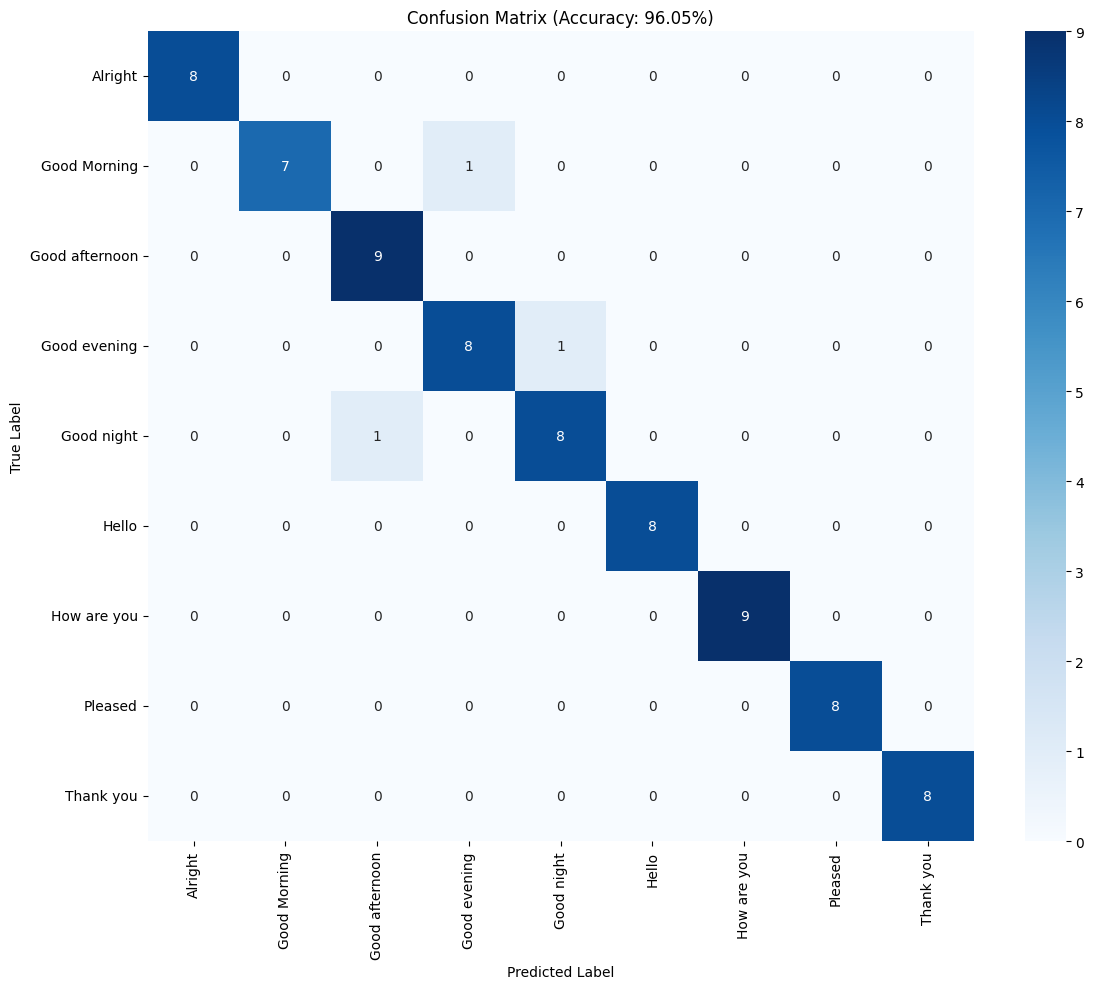

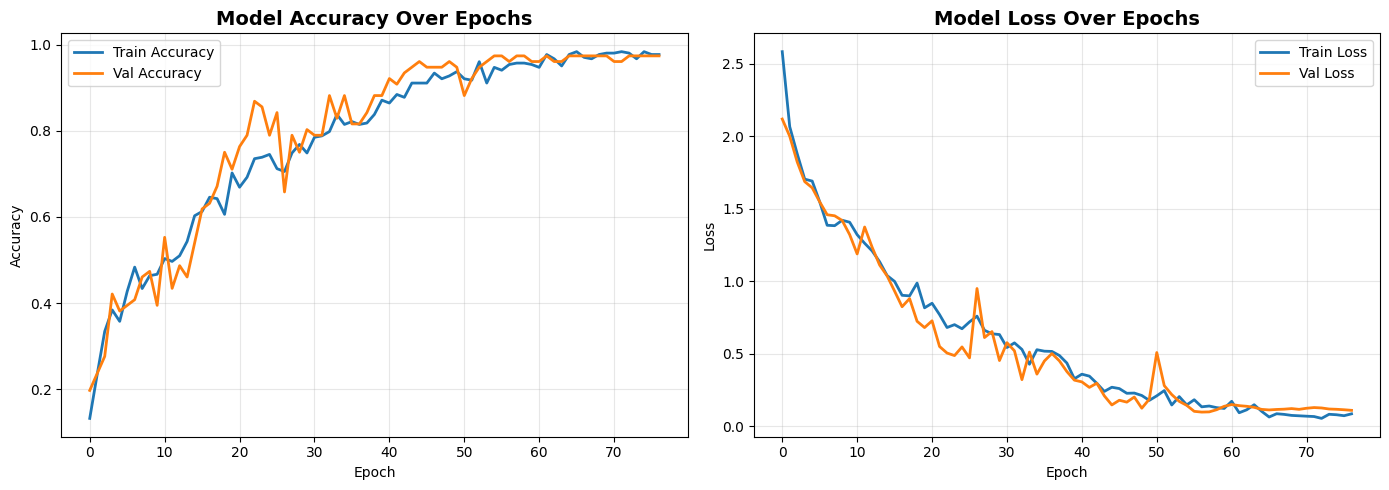


✅ Pipeline completed successfully!
📁 Outputs saved:
   - best_isl_model.keras
   - processed_landmarks.pkl
   - confusion_matrix.png
   - training_history.png


In [ ]:
# Step 7: Evaluate
print("\n" + "=" * 80)
print("STEP 7: EVALUATION")
print("=" * 80)

evaluate_model(model, X_test, y_test_cat, class_names, history)

print("\n✅ Pipeline completed successfully!")
print("📁 Outputs saved:")
print("   - best_isl_gcn_model.keras")
print("   - processed_landmarks.pkl")
print("   - confusion_matrix.png")
print("   - training_history.png")

# **Model Testing**

In [7]:
def predict_from_video(video_path, model_path, max_frames=60,
                       include_pose=True, include_face=False):

    # Load class names
    with open('outputs/processed_landmarks.pkl', 'rb') as f:
        data = pickle.load(f)
    class_names = data['class_names']

    # Rebuild architecture + load weights (bypasses broken config)
    A = get_adjacency_matrix()
    model = build_gcn_lstm_model(
        num_joints=75,
        joint_features=4,
        seq_len=max_frames,
        num_classes=len(class_names),
        A=A
    )
    dummy = np.zeros((1, max_frames, 75 * 4), dtype=np.float32)
    model(dummy)  # build all layers
    model.load_weights(model_path)

    # Extract landmarks
    extractor = MediaPipeLandmarkExtractor(include_pose=include_pose, include_face=include_face)
    landmark_seq = extractor.process_video(video_path, max_frames=max_frames, augment_params=None)

    if np.all(landmark_seq == 0):
        print("⚠️ Warning: No landmarks detected in video!")
        return None, 0.0, None

    landmark_seq = landmark_seq[np.newaxis]
    landmark_gcn = reshape_landmarks_for_gcn(landmark_seq)
    landmark_input = landmark_gcn.reshape(1, max_frames, 75 * 4)

    probs = model.predict(landmark_input, verbose=0)[0]
    pred_idx = np.argmax(probs)
    predicted_label = class_names[pred_idx]
    confidence = probs[pred_idx]

    top3_indices = np.argsort(probs)[-3:][::-1]
    print(f"\n🎯 Top 3 Predictions:")
    for i, idx in enumerate(top3_indices, 1):
        print(f"   {i}. {class_names[idx]}: {probs[idx]:.3f}")
    print(f"\n✅ Final Prediction: {predicted_label} (confidence: {confidence:.3f})")

    return predicted_label, confidence, probs

In [10]:
# Usage
predict_from_video(
    video_path='Good night.mp4',
    model_path='outputs/best_isl_gcn_model.keras'
)


🎯 Top 3 Predictions:
   1. Good night: 0.717
   2. Thank you: 0.130
   3. Alright: 0.127

✅ Final Prediction: Good night (confidence: 0.717)


('Good night',
 np.float32(0.7169746),
 array([1.2673143e-01, 8.1556544e-05, 2.5214036e-03, 2.2729194e-02,
        7.1697462e-01, 1.0135536e-05, 6.0370355e-04, 8.5508604e-05,
        1.3026243e-01], dtype=float32))